<>:10: SyntaxWarning: invalid escape sequence '\L'
<>:10: SyntaxWarning: invalid escape sequence '\L'
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22760\2838310590.py:10: SyntaxWarning: invalid escape sequence '\L'
  dataset_dir = 'D:\Learn Python\Vietnamese_Food_Project\data'


✅ Đã tìm thấy thư mục: D:\Learn Python\Vietnamese_Food_Project\data. Đang tiến hành đọc dữ liệu...
📊 Đang vẽ biểu đồ thống kê...


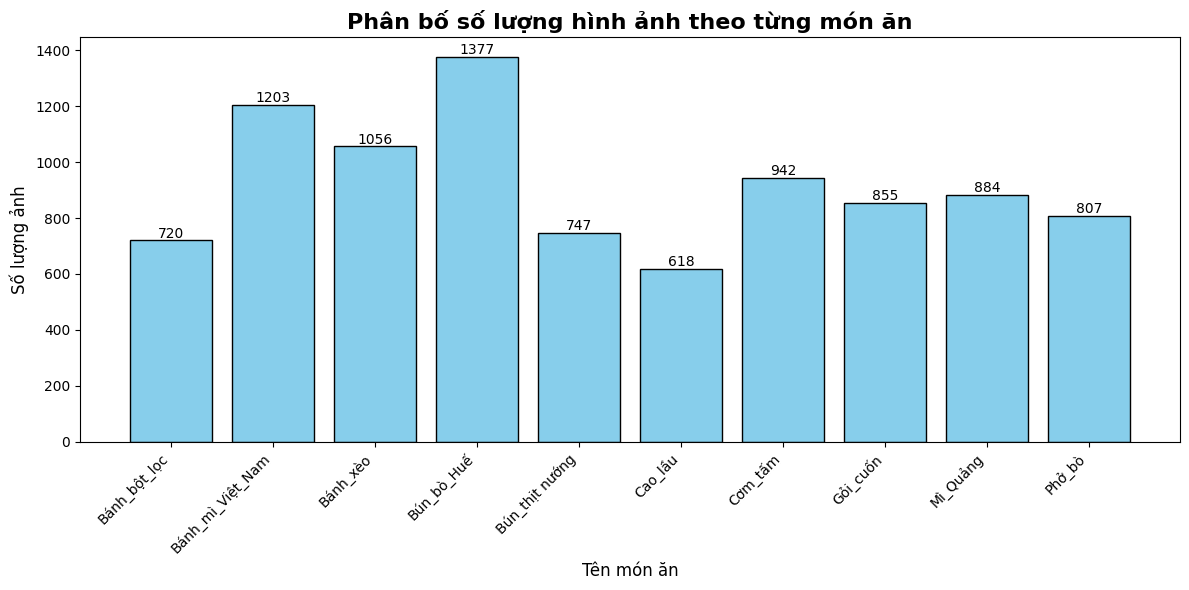

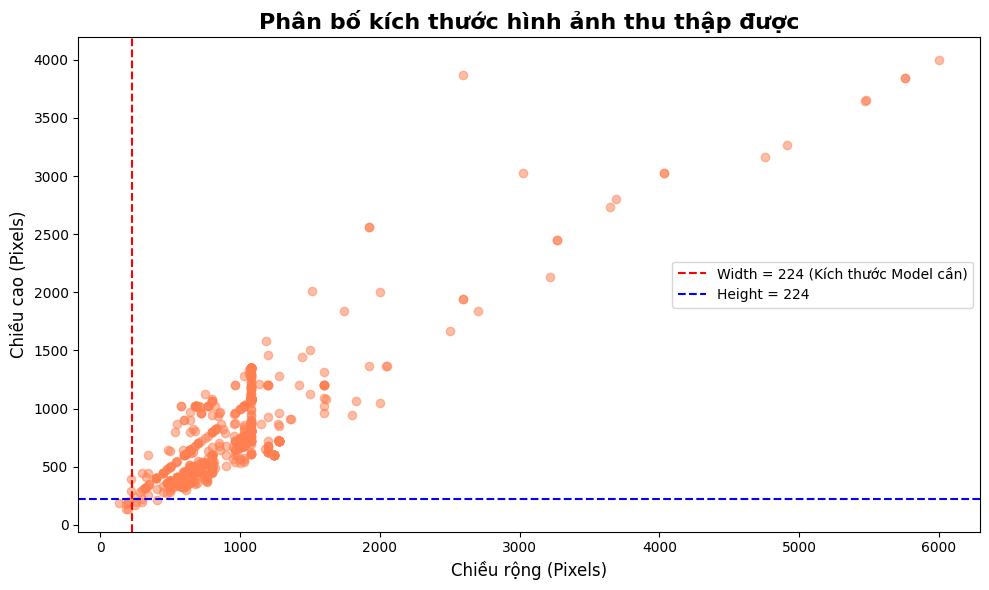

In [5]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random
import numpy as np

dataset_dir = 'D:\Learn Python\Vietnamese_Food_Project\data'

if not os.path.exists(dataset_dir):
    print(f"Lỗi: Không tìm thấy thư mục tại '{dataset_dir}'. Vui lòng kiểm tra lại đường dẫn!")
    exit()

print(f"Đã tìm thấy thư mục: {dataset_dir}. Đang tiến hành đọc dữ liệu...")

# 1.THỐNG KÊ SỐ LƯỢNG ẢNH MỖI LỚP (BAR CHART)
class_names = []
class_counts = []
image_sizes = []

for folder_name in os.listdir(dataset_dir):
    folder_path = os.path.join(dataset_dir, folder_name)
    if os.path.isdir(folder_path):
        images = os.listdir(folder_path)
        class_names.append(folder_name)
        class_counts.append(len(images))

        sample_images = random.sample(images, min(100, len(images)))
        for img_name in sample_images:
            try:
                with Image.open(os.path.join(folder_path, img_name)) as img:
                    image_sizes.append(img.size)  # (Width, Height)
            except:
                pass

print("Đang vẽ biểu đồ thống kê...")

# Vẽ Bar Chart
plt.figure(figsize=(12, 6))
plt.bar(class_names, class_counts, color='skyblue', edgecolor='black')
plt.title('Phân bố số lượng hình ảnh theo từng món ăn', fontsize=16, fontweight='bold')
plt.xlabel('Tên món ăn', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)
plt.xticks(rotation=45, ha='right')
for i, count in enumerate(class_counts):
    plt.text(i, count + 10, str(count), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# 2. THỐNG KÊ KÍCH THƯỚC ẢNH (SCATTER PLOT)
widths, heights = zip(*image_sizes)

plt.figure(figsize=(10, 6))
plt.scatter(widths, heights, alpha=0.5, color='coral')
plt.title('Phân bố kích thước hình ảnh thu thập được', fontsize=16, fontweight='bold')
plt.xlabel('Chiều rộng (Pixels)', fontsize=12)
plt.ylabel('Chiều cao (Pixels)', fontsize=12)
plt.axvline(x=224, color='red', linestyle='--', label='Width = 224 (Kích thước Model cần)')
plt.axhline(y=224, color='blue', linestyle='--', label='Height = 224')
plt.legend()
plt.tight_layout()
plt.show()

